# Simple real NISAR GUNW workflow

This notebook is intentionally small. Set `SNOWIN_GUNW` to a local NISAR GUNW product and optionally set `SNOWIN_NISAR_DEM` to a cached NISAR-modified Copernicus DEM. The product is opened first for inspection; the slower incidence calculation is an explicit second step.

In [3]:
import os
from html import escape
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display

from snowin import compute_dswe
from snowin.io import add_gunw_incidence, open_gunw
from snowin.io.gunw import read_attrs_hdf5, read_scalar_hdf5

gunw_text = os.environ.get("SNOWIN_GUNW")
if not gunw_text:
    gunw_text = input("Enter the path to a local NISAR GUNW product: ").strip()
if not gunw_text:
    raise RuntimeError("A local NISAR GUNW product path is required.")
GUNW_PATH = Path(gunw_text).expanduser().resolve()
DEM_PATH = os.environ.get("SNOWIN_NISAR_DEM")
DEM_CACHE = Path(os.environ.get("SNOWIN_DEM_CACHE", "~/.cache/snowin/dem")).expanduser()
def _format_metadata_value(value):
    if isinstance(value, (float, np.floating)):
        return f"{float(value):.6g}"
    return str(value)

def _display_metadata(title, attrs, fields):
    rows = "".join(
        f"<tr><th><code>{escape(field)}</code></th><td>{escape(_format_metadata_value(attrs.get(field, 'not present')))}</td></tr>"
        for field in fields
    )
    display(HTML(f"<h3>{escape(title)}</h3><table><thead><tr><th>Field</th><th>Value</th></tr></thead><tbody>{rows}</tbody></table>"))

display(HTML(
    f"<h3>Inputs</h3><ul><li><b>GUNW product</b>: <code>{escape(str(GUNW_PATH))}</code></li><li><b>NISAR DEM</b>: <code>{escape(str(DEM_PATH or 'automatic download/cache'))}</code></li></ul>"
))

Enter the path to a local NISAR GUNW product:  /Users/jtarrico/ch13_nisar_prelim/data/nisar/gunw/provisional/erb/asc/T019_F021/NISAR_L2_PR_GUNW_004_019_A_021_005_4000_SH_20251030T121115_20251030T121143_20251111T121116_20251111T121144_P05023_N_F_J_001


## Inspect product metadata

In [4]:
phase_path = (
    "science/LSAR/GUNW/grids/frequencyA/unwrappedInterferogram/HH/unwrappedPhase"
)
height_path = "science/LSAR/GUNW/metadata/radarGrid/heightAboveEllipsoid"
reference_path = "science/LSAR/identification/referenceZeroDopplerStartTime"
secondary_path = "science/LSAR/identification/secondaryZeroDopplerStartTime"

phase_attrs = read_attrs_hdf5(GUNW_PATH, phase_path)
height_attrs = read_attrs_hdf5(GUNW_PATH, height_path)
_display_metadata("Phase layer metadata", phase_attrs, ["units", "description", "grid_mapping", "min_value", "max_value", "mean_value", "sample_stddev"])
_display_metadata("Radar-grid height metadata", height_attrs, ["standard_name", "description", "units"])
reference_time = read_scalar_hdf5(GUNW_PATH, reference_path)
secondary_time = read_scalar_hdf5(GUNW_PATH, secondary_path)
display(HTML(f"<h3>Acquisition times</h3><ul><li><b>Reference</b>: <code>{escape(str(reference_time))}</code></li><li><b>Secondary</b>: <code>{escape(str(secondary_time))}</code></li></ul>"))

Field,Value
units,radians
description,Unwrapped interferogram between HH layers
grid_mapping,projection
min_value,-27.8605
max_value,13.9805
mean_value,-8.56116
sample_stddev,8.53149


Field,Value
standard_name,height_above_reference_ellipsoid
description,Height values above WGS84 Ellipsoid corresponding to the radar grid
units,meters


## Open and inspect the GUNW with SnowIn

This step does not download a DEM or compute incidence. Phase/product arrays remain lazy when Dask is installed, so you can inspect metadata before starting the slower geometry step.

## Open and inspect the GUNW with SnowIn

This step does not download a DEM or compute incidence. Phase/product arrays remain lazy when Dask is installed, so you can inspect metadata before starting the slower geometry step.

In [5]:
pair = open_gunw(GUNW_PATH, chunks="auto")
display(pair)
display(HTML(
    f"<p><b>Phase transform</b>: <code>{pair.attrs.get('phase_transform')}</code><br><b>Incidence status</b>: <code>{pair.attrs.get('incidence_angle_status')}</code><br><b>Wavelength</b>: <code>{pair.attrs.get('wavelength_m'):.9f} m</code></p>"
))

[snowin] opening GUNW phase data from NISAR_L2_PR_GUNW_004_019_A_021_005_4000_SH_20251030T121115_20251030T121143_20251111T121116_20251111T121144_P05023_N_F_J_001


<xarray.Dataset> Size: 230MB
Dimensions:              (y: 4347, x: 4410)
Coordinates:
  * y                    (y) float64 35kB 4.445e+06 4.445e+06 ... 4.098e+06
  * x                    (x) float64 35kB 2.42e+05 2.42e+05 ... 5.947e+05
    spatial_ref          uint32 4B 32613
Data variables:
    phase                (y, x) float32 77MB dask.array<chunksize=(4347, 4410), meta=np.ndarray>
    coherence            (y, x) float32 77MB dask.array<chunksize=(4347, 4410), meta=np.ndarray>
    connected_component  (y, x) float32 77MB dask.array<chunksize=(4347, 4410), meta=np.ndarray>
Attributes: (12/15)
    snowin_schema_version:               0.1-draft
    product_kind:                        pairwise_interferogram
    reference_time:                      2025-10-30T12:11:15Z
    secondary_time:                      2025-11-11T12:11:16Z
    temporal_edge:                       reference_to_secondary
    phase_difference_definition:         secondary_minus_reference
    ...                                  ...
    source_product_type:                 NISAR_GUNW
    source_reader:                       snowin.io.nisar_product.open_gunw
    source_granule_id:                   NISAR_L2_PR_GUNW_004_019_A_021_005_4...
    source_dataset_paths:                {"center_frequency": "/science/LSAR/...
    wavelength_source:                   NISAR GUNW centerFrequency metadata ...
    incidence_angle_status:              not_computed

## Add local incidence when ready

This explicit call requires the GUNW path and appends `incidence_angle` to the already-open dataset. It is the step that may download/reproject the NISAR DEM and read the GUNW LOS cube.

In [6]:
incidence_kwargs = {"dem_cache_dir": DEM_CACHE, "progress": True}
if DEM_PATH:
    incidence_kwargs["nisar_cop30_dem"] = Path(DEM_PATH).expanduser()

add_gunw_incidence(pair, GUNW_PATH, **incidence_kwargs)
display(pair[["incidence_angle"]])
display(HTML(
    f"<p><b>Incidence status</b>: <code>{pair.attrs.get('incidence_angle_status')}</code><br><b>DEM source</b>: <code>{pair.attrs.get('dem_source')}</code></p>"
))

[snowin] starting explicit GUNW incidence calculation
[snowin] preparing DEM for local incidence
[snowin] locating NISAR Copernicus DEM tiles for GUNW
[snowin] using cached NISAR DEM mosaic /Users/jtarrico/.cache/snowin/dem/NISAR_L2_PR_GUNW_004_019_A_021_005_4000_SH_20251030T121115_20251030T121143_20251111T121116_20251111T121144_P05023_N_F_J_001_nisar_cop30.tif
[snowin] reading GUNW radar-grid LOS vectors
[snowin] computing terrain-surface incidence from DEM and GUNW LOS
[snowin] interpolating GUNW LOS vectors onto the DEM surface
[snowin] deriving terrain normals and incidence angles
[snowin] incidence_angle appended to SnowIn dataset


<xarray.Dataset> Size: 77MB
Dimensions:          (y: 4347, x: 4410)
Coordinates:
  * y                (y) float64 35kB 4.445e+06 4.445e+06 ... 4.098e+06
  * x                (x) float64 35kB 2.42e+05 2.42e+05 ... 5.946e+05 5.947e+05
    spatial_ref      uint32 4B 32613
Data variables:
    incidence_angle  (y, x) float32 77MB 1.015 1.077 1.15 ... 0.601 0.6105
Attributes: (12/38)
    snowin_schema_version:               0.1-draft
    product_kind:                        pairwise_interferogram
    reference_time:                      2025-10-30T12:11:15Z
    secondary_time:                      2025-11-11T12:11:16Z
    temporal_edge:                       reference_to_secondary
    phase_difference_definition:         secondary_minus_reference
    ...                                  ...
    dem_product:                         Modified Copernicus DEM for NISAR
    dem_height_reference:                ellipsoidal
    vertical_datum_transform:            not applied
    coordinate_orientation:              GUNW projected x/y phase-grid coordi...
    dem_input:                           /Users/jtarrico/.cache/snowin/dem/NI...
    incidence_angle_resampling:          NISAR Copernicus DEM bilinear reproj...

## Preview phase, local incidence, and pairwise dSWE

<xarray.DataArray 'dswe' (y: 4347, x: 4410)> Size: 77MB
dask.array<truediv, shape=(4347, 4410), dtype=float32, chunksize=(4347, 4410), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 35kB 4.445e+06 4.445e+06 ... 4.098e+06 4.098e+06
  * x            (x) float64 35kB 2.42e+05 2.42e+05 ... 5.946e+05 5.947e+05
    spatial_ref  uint32 4B 32613
Attributes: (12/19)
    description:                         Unwrapped interferogram between HH l...
    grid_mapping:                        spatial_ref
    max_value:                           13.980478286743164
    mean_value:                          -8.561155319213867
    min_value:                           -27.86049461364746
    sample_stddev:                       8.531492233276367
    ...                                  ...
    incidence_angle_reference:           local
    wavelength_m:                        0.2419632429378531
    alpha:                               1.0
    snow_path_constant:                  1.59
    equation:                            dSWE = phase * wavelength_m / (2*pi*...
    scientific_reference:                Leinss et al. (2015), Eq. 18

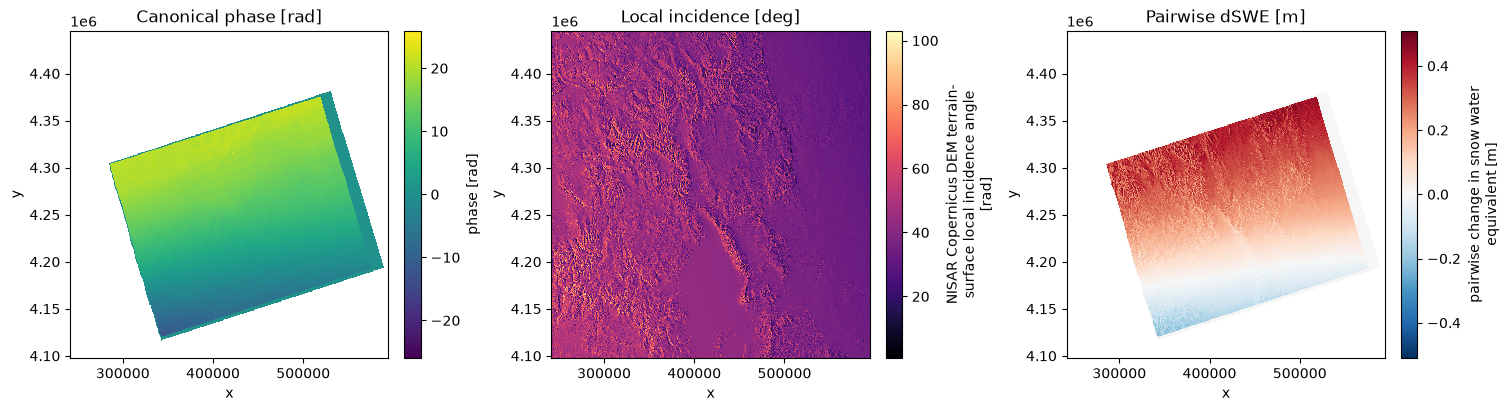

In [7]:
step = max(1, min(pair.sizes.values()) // 600)
phase_preview = pair["phase"].isel(y=slice(None, None, step), x=slice(None, None, step))
incidence_preview = np.rad2deg(pair["incidence_angle"]).isel(
    y=slice(None, None, step), x=slice(None, None, step)
)
valid_geometry = (pair["incidence_angle"] >= 0) & (pair["incidence_angle"] < np.pi / 2)
safe_incidence = pair["incidence_angle"].where(valid_geometry)
dswe = compute_dswe(
    pair["phase"],
    safe_incidence,
    wavelength_m=float(pair.attrs["wavelength_m"]),
)
display(dswe)
dswe_preview = dswe.isel(y=slice(None, None, step), x=slice(None, None, step))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
phase_preview.plot(ax=axes[0], cmap="viridis")
axes[0].set_title("Canonical phase [rad]")
incidence_preview.plot(ax=axes[1], cmap="magma")
axes[1].set_title("Local incidence [deg]")
dswe_preview.plot(ax=axes[2], cmap="RdBu_r")
axes[2].set_title("Pairwise dSWE [m]")
plt.show()

In [8]:
display(HTML(
    f"<h3>Output checks</h3><table><tr><th>Check</th><th>Value</th></tr><tr><td>Phase definition</td><td><code>{pair.attrs.get('phase_difference_definition')}</code></td></tr><tr><td>Incidence reference</td><td><code>{pair['incidence_angle'].attrs.get('incidence_angle_reference')}</code></td></tr><tr><td>Finite phase fraction</td><td>{float(np.isfinite(phase_preview).mean()):.4f}</td></tr><tr><td>Finite dSWE fraction</td><td>{float(np.isfinite(dswe_preview).mean()):.4f}</td></tr></table>"
))
pair.close()

Check,Value
Phase definition,secondary_minus_reference
Incidence reference,local
Finite phase fraction,0.4153
Finite dSWE fraction,0.4153
